## **Cross-Platform Review Sentiment & Fake-Review Detection (Flipkart vs Amazon)**

**STUDENT NAME** : **Marati Siri Vennela**

**STUDENT ID**   : **23080951**

**SUPERVISOR**   : **Klass**

**MODULE**       : **7PAM2002 – Data Science Project**

**SEMESTER**     : **A 2025/2026**

# **AIM OF THE PROJECT**:

TO Correlate product review samples and sentiments between flipkart and amazon,investigate whether review attributes (ratings, word count of review,category etc.,) can specify suspicious or fake reviews. the assignment also estimates which stage shows strong customer satisfaction levels and capably shows machine learning workflow using light and fast models.

# **RESEARCH QUESTION:**



1.   Do average ratings and reviews word count vary between flipkart and amazon?

2.   which product types collect the most utmost or Inaccurate ratings?

3.   can a ML model (TF-IDF + Logistic Regression) detect likely fake or       
     suspicious reviews efficiently?






# **DATASET:**

flipkart_path = https://www.kaggle.com/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset

amazon_path   = https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews


**IMPORT LIBRARIES**:

In [ ]:
# 1: Imports
import pandas as pd
import numpy as np
import re
import string

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# **LOAD THE DATASET**:

In [ ]:
#2:Load raw datasets
df_flip_raw = pd.read_csv('flipkart.csv', encoding='utf-8', on_bad_lines='skip')
df_amz_raw  = pd.read_csv('amazon.csv',   encoding='utf-8', on_bad_lines='skip')

print("Flipkart columns:\n", df_flip_raw.columns)
print("\nAmazon columns:\n", df_amz_raw.columns)


Flipkart columns:
 Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')

Amazon columns:
 Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


#lets clean the flipkart dataset

In [ ]:
#  3: Clean Flipkart
df_flip = df_flip_raw.rename(columns={
    'product_name': 'category',
    'Review': 'review_text',
    'Rate': 'rating',
    'Sentiment': 'label'
})

# Map text sentiment to numeric labels
df_flip['label'] = df_flip['label'].astype(str).str.strip().str.lower().map({
    'positive': 1,
    'negative': 0,
    'neutral': 2
})

# Drop rows with missing review or label
df_flip = df_flip.dropna(subset=['review_text', 'label'])

# Set platform column
df_flip['platform'] = 'Flipkart'

print(df_flip[['review_text','rating','label','platform']].head())
print("Flipkart shape:", df_flip.shape)


       review_text rating  label  platform
0           super!      5      1  Flipkart
1          awesome      5      1  Flipkart
2             fair      3      1  Flipkart
3  useless product      1      0  Flipkart
4             fair      3      2  Flipkart
Flipkart shape: (180388, 7)


#lets clean amazon dataset

In [ ]:
#4: Clean Amazon
df_amz = df_amz_raw.rename(columns={
    'ProductId': 'category',
    'Text': 'review_text',
    'Score': 'rating'
})

# Drop missing rating or review_text
df_amz = df_amz.dropna(subset=['rating', 'review_text'])

# Ensure rating is numeric
df_amz['rating'] = pd.to_numeric(df_amz['rating'], errors='coerce')
df_amz = df_amz.dropna(subset=['rating'])

# Map rating (1-5) to sentiment label: 0=neg, 1=pos, 2=neutral
def rating_to_label(score):
    if score <= 2:
        return 0      # negative
    elif score == 3:
        return 2      # neutral
    else:
        return 1      # positive

df_amz['label'] = df_amz['rating'].apply(rating_to_label)

df_amz['platform'] = 'Amazon'

print(df_amz[['review_text','rating','label','platform']].head())
print("Amazon shape:", df_amz.shape)


                                         review_text  rating  label platform
0  I have bought several of the Vitality canned d...       5      1   Amazon
1  Product arrived labeled as Jumbo Salted Peanut...       1      0   Amazon
2  This is a confection that has been around a fe...       4      1   Amazon
3  If you are looking for the secret ingredient i...       2      0   Amazon
4  Great taffy at a great price.  There was a wid...       5      1   Amazon
Amazon shape: (568454, 12)


#text cleaning

In [ ]:
#  5: Text cleaning function
def clean_text(text):
    text = str(text).lower()
    # remove HTML tags like <br>, <br/>, <...>
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove digits
    text = re.sub(r'\d+', ' ', text)
    # collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


#applt text cleaning

In [ ]:
#  6: Apply cleaning to both datasets
df_flip['cleaned_review'] = df_flip['review_text'].apply(clean_text)
df_amz['cleaned_review']  = df_amz['review_text'].apply(clean_text)

print("Example Flipkart cleaned review:\n", df_flip['cleaned_review'].iloc[0])
print("\nExample Amazon cleaned review:\n", df_amz['cleaned_review'].iloc[0])


Example Flipkart cleaned review:
 super

Example Amazon cleaned review:
 i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most


#Keep Only Needed Columns & Merge

In [ ]:
#7: Select consistent columns and merge
use_cols = ['review_text', 'rating', 'label', 'platform', 'cleaned_review']

df_flip_use = df_flip[use_cols].copy()
df_amz_use  = df_amz[use_cols].copy()

df_all = pd.concat([df_flip_use, df_amz_use], axis=0, ignore_index=True)

print("Merged shape:", df_all.shape)
print("\nPlatform counts:\n", df_all['platform'].value_counts())
print("\nLabel counts:\n", df_all['label'].value_counts())


Merged shape: (748842, 5)

Platform counts:
 platform
Amazon      568454
Flipkart    180388
Name: count, dtype: int64

Label counts:
 label
1    590953
0    106438
2     51451
Name: count, dtype: int64


#Remove Missing & Duplicates

In [ ]:
# 8: Drop any remaining missing values
df_all = df_all.dropna(subset=['cleaned_review', 'label', 'rating'])
df_all.reset_index(drop=True, inplace=True)

# Drop duplicate reviews based on cleaned text
df_all = df_all.drop_duplicates(subset=['cleaned_review'])
df_all.reset_index(drop=True, inplace=True)

print("After cleaning, shape:", df_all.shape)
print("Nulls:\n", df_all.isnull().sum())


After cleaning, shape: (394272, 5)
Nulls:
 review_text       0
rating            0
label             0
platform          0
cleaned_review    0
dtype: int64


#Basic EDA: Theme + Review Length

In [ ]:
# CELL 9: Setup style + review length
sns.set_theme(style="whitegrid", font_scale=1.1)
platform_palette  = ['#FF6F61', '#4E79A7']           # Flipkart, Amazon
sentiment_palette = ['#E15759', '#59A14F', '#F28E2B'] # neg, pos, neu

df_all['review_len'] = df_all['cleaned_review'].str.split().apply(len)

print(df_all[['platform','rating','label','review_len']].head())


   platform rating  label  review_len
0  Flipkart      5      1           1
1  Flipkart      5      1           1
2  Flipkart      3      1           1
3  Flipkart      1      0           2
4  Flipkart      5      1           2


#Platform counts

/tmp/ipython-input-155057675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='platform', palette=platform_palette)


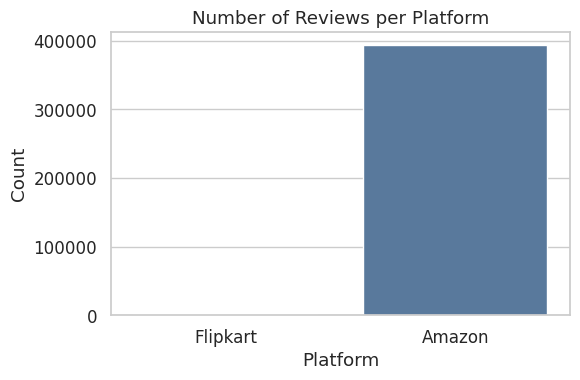

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_all, x='platform', palette=platform_palette)
plt.title("Number of Reviews per Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#Overall sentiment distribution

/tmp/ipython-input-1547698208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_all, x='label', palette=sentiment_palette)


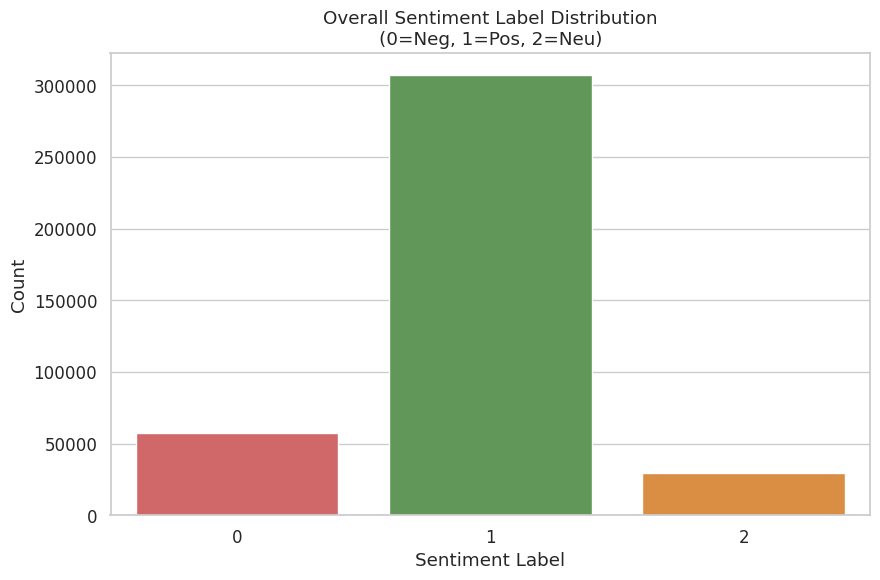

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(9,6))
sns.countplot(data=df_all, x='label', palette=sentiment_palette)
plt.title("Overall Sentiment Label Distribution\n(0=Neg, 1=Pos, 2=Neu)")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.savefig("sentiment_LABEL.png", dpi=300, bbox_inches='tight')


#Review length distribution

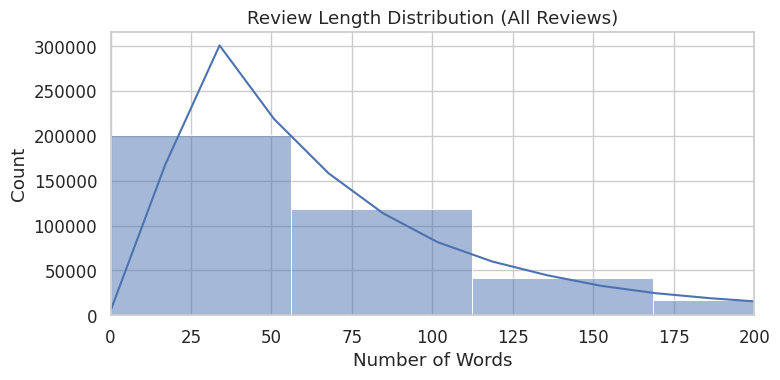

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df_all['review_len'], bins=60, kde=True)
plt.title("Review Length Distribution (All Reviews)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.savefig("review_length_dist.png", dpi=300, bbox_inches='tight')

#Rating distribution by platform

/tmp/ipython-input-2745676528.py:18: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


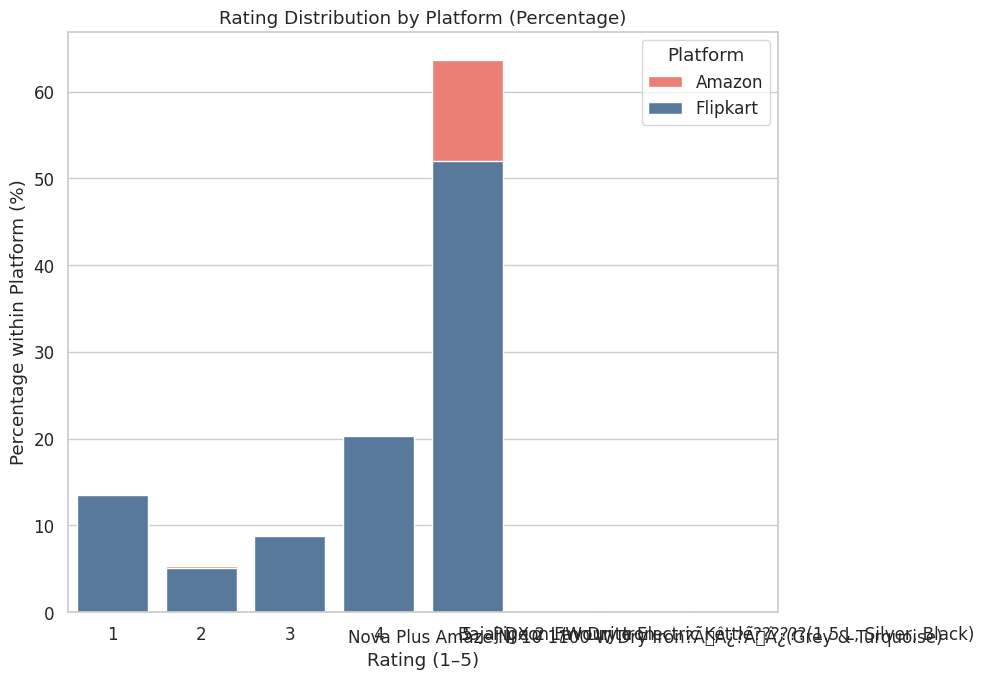

<Figure size 640x480 with 0 Axes>

In [ ]:
rating_dist = df_all.groupby(['platform','rating']).size().reset_index(name='count')
rating_dist['percent'] = rating_dist.groupby('platform')['count'].transform(
    lambda x: 100 * x / x.sum()
)

plt.figure(figsize=(10,7))
sns.barplot(
    data=rating_dist,
    x='rating',
    y='percent',
    hue='platform',
    palette=platform_palette
)
plt.title("Rating Distribution by Platform (Percentage)")
plt.xlabel("Rating (1–5)")
plt.ylabel("Percentage within Platform (%)")
plt.legend(title="Platform")
plt.tight_layout()
plt.show()
plt.savefig("rating_distribution_by_platform.png", dpi=300, bbox_inches='tight')


#word cloud

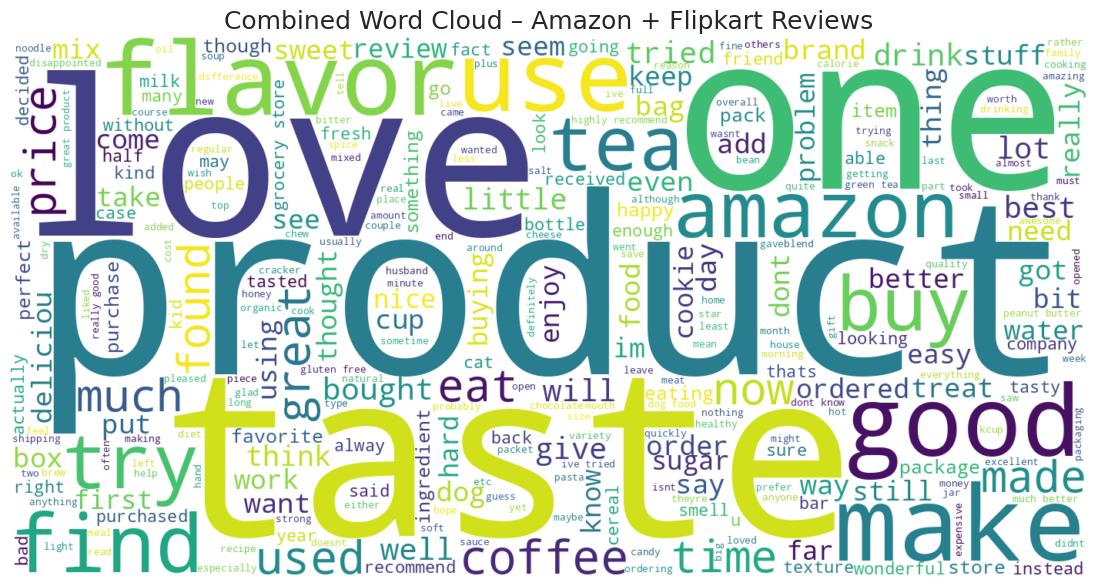

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned reviews
all_text = " ".join(df_all['cleaned_review'].astype(str))

# Create word cloud
wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='viridis',
    max_words=300
).generate(all_text)

# Plot
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Combined Word Cloud – Amazon + Flipkart Reviews", fontsize=18)

# Save image
plt.savefig("wordcloud_combined.png", dpi=300, bbox_inches='tight')
plt.show()


#volin + box plot

/tmp/ipython-input-3810459506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x='platform', y='review_len',


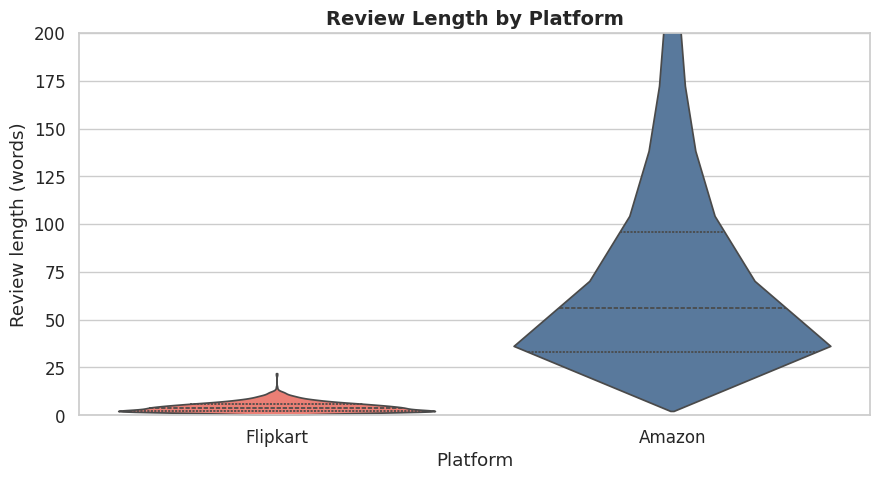

/tmp/ipython-input-3810459506.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='platform', y='review_len',


<Figure size 640x480 with 0 Axes>

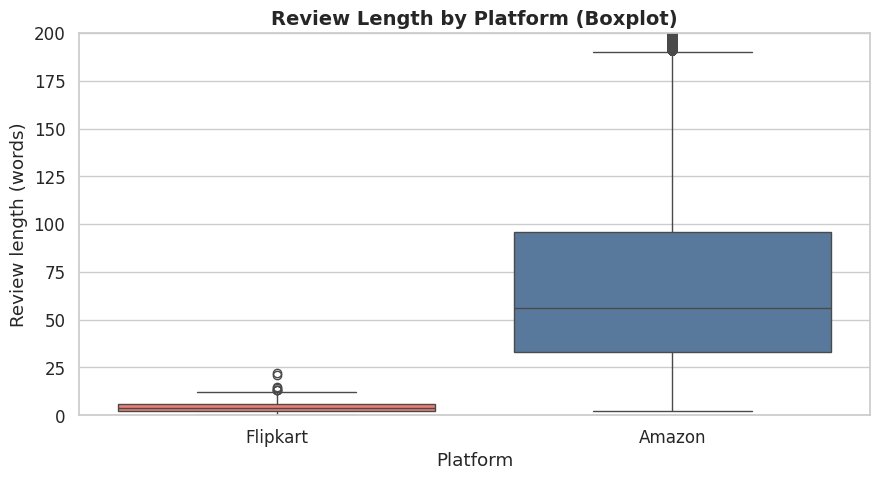

<Figure size 640x480 with 0 Axes>

In [ ]:
# Review length distribution by platform (violin + box)
plt.figure(figsize=(9,5))
sns.violinplot(data=df_all, x='platform', y='review_len',
               palette=platform_palette, inner='quartile', cut=0)
plt.title("Review Length by Platform", fontsize=14, weight='bold')
plt.xlabel("Platform")
plt.ylabel("Review length (words)")
plt.ylim(0, 200)
plt.tight_layout()
plt.show()
plt.savefig("volin.png", dpi=300, bbox_inches='tight')

plt.figure(figsize=(9,5))
sns.boxplot(data=df_all, x='platform', y='review_len',
            palette=platform_palette)
plt.title("Review Length by Platform (Boxplot)", fontsize=14, weight='bold')
plt.xlabel("Platform")
plt.ylabel("Review length (words)")
plt.ylim(0, 200)
plt.tight_layout()
plt.show()
plt.savefig("boxplot.png", dpi=300, bbox_inches='tight')

#Prepare Data for Modelling

In [ ]:
#11: Prepare X, y and train/test split

X = df_all['cleaned_review']
y = df_all['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 315417
Test size : 78855


#TF-IDF Vectorisation

In [ ]:
#  12: TF-IDF vectorisation
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2)
)

Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

print("Xtr shape:", Xtr.shape)
print("Xte shape:", Xte.shape)


Xtr shape: (315417, 5000)
Xte shape: (78855, 5000)


#Logistic Regression Model

In [ ]:
# 13: Logistic Regression baseline
lr = LogisticRegression(max_iter=1000)

lr.fit(Xtr, y_train)
y_pred_lr = lr.predict(Xte)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8599074250206075

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.73      0.65      0.69     11441
           1       0.89      0.97      0.93     61462
           2       0.47      0.15      0.22      5952

    accuracy                           0.86     78855
   macro avg       0.70      0.59      0.61     78855
weighted avg       0.84      0.86      0.84     78855



#SVM Model (LinearSVC)

In [ ]:
#  14: SVM (LinearSVC)
svm = LinearSVC()

svm.fit(Xtr, y_train)
y_pred_svm = svm.predict(Xte)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8594635723796842

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.72      0.66      0.69     11441
           1       0.89      0.97      0.93     61462
           2       0.53      0.09      0.15      5952

    accuracy                           0.86     78855
   macro avg       0.71      0.57      0.59     78855
weighted avg       0.84      0.86      0.83     78855



#Simple Hyperparameter Tuning for SVM (C value)

In [ ]:
# CELL 15: Hyperparameter tuning for SVM C

param_grid = {'C': [0.1, 1, 5]}

svm_base = LinearSVC()

grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_svm.fit(Xtr, y_train)

print("Best params:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(Xte)

print("\nTuned SVM Accuracy:", accuracy_score(y_test, y_pred_best_svm))
print("\nClassification Report (Tuned SVM):\n")
print(classification_report(y_test, y_pred_best_svm))


Best params: {'C': 5}

Tuned SVM Accuracy: 0.8594382093716315

Classification Report (Tuned SVM):

              precision    recall  f1-score   support

           0       0.71      0.66      0.69     11441
           1       0.89      0.97      0.93     61462
           2       0.53      0.09      0.15      5952

    accuracy                           0.86     78855
   macro avg       0.71      0.57      0.59     78855
weighted avg       0.84      0.86      0.83     78855



#SVM Confusion Matrix

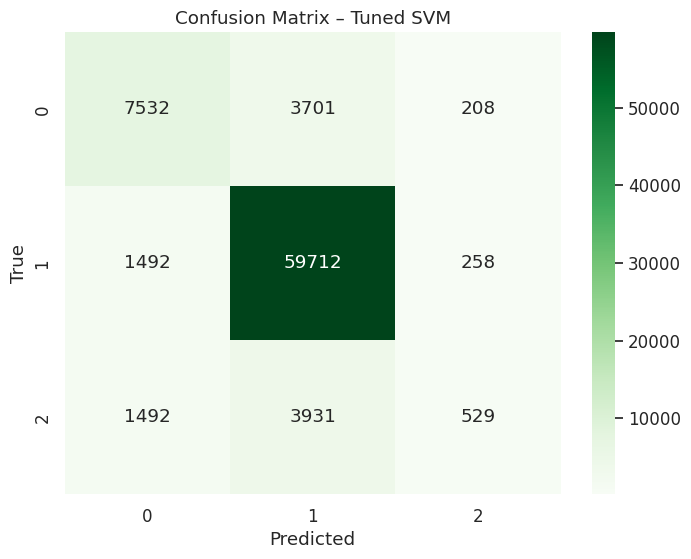

<Figure size 640x480 with 0 Axes>

In [ ]:

from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Tuned SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
plt.savefig("confusion matrix_svm.png", dpi=300, bbox_inches='tight')

#Model Comparison Table

In [ ]:
from sklearn.metrics import accuracy_score

# Recompute accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Logistic Regression accuracy:", acc_lr)
print("Tuned SVM accuracy:", acc_svm)


Logistic Regression accuracy: 0.8599074250206075
Tuned SVM accuracy: 0.8594635723796842


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned SVM"],
    "Accuracy": [acc_lr, acc_svm]
})

results_df

,Model,Accuracy
0,Logistic Regression,0.859907
1,Tuned SVM,0.859464


/tmp/ipython-input-3573990448.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="mako")


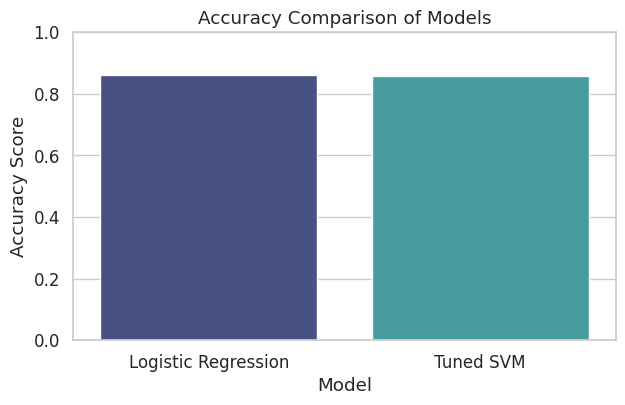

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="mako")
plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy Score")
plt.ylim(0,1)
plt.show()
plt.savefig("accuracy comparison.png", dpi=300, bbox_inches='tight')